## Segmentation

In [1]:
import pandas as pd
import numpy as np

# Load the data

In [2]:
# load data header (columns)
with open("census-bureau.columns") as f:
    columns = [c.strip() for c in f.readlines()]

# load data
data = pd.read_csv("census-bureau.data", header=None, names=columns)

# Preprocessing

We skip EDA since we have done it in the classification assignment

In [3]:
object_cols = data.select_dtypes(include=["object"]).columns
for col in object_cols:
    data[col] = data[col].str.strip()   # remove extra whitespaces in string columns

In [4]:
# convert all the ambiguous responses to nan

missing_tokens_map = {
    "Do not know": np.nan,
    "Unknown": np.nan,
    "NA": np.nan,
    "": np.nan,
    "?": np.nan  # include more possibilities for missing data
}

data = data.replace(missing_tokens_map)

In [ ]:
seg_data = data.drop(columns=["label", "weight", "year"]).copy() # drop labels and years since we do not want to cluster based on these pieces of information, and keep the weights until model interpretation

In [7]:
weights = data["weight"].copy()

Select features that lead to a more interpretable clusting result in order to provide business suggestions

In [8]:
seg_features = [
    "age",
    "sex",
    "race",
    "hispanic origin",
    "education",
    "marital stat",
    "class of worker",
    "major industry code",
    "major occupation code",
    "full or part time employment stat",
    "wage per hour",
    "capital gains",
    "capital losses",
    "dividends from stocks",
    "own business or self employed",
    "weeks worked in year",
    "tax filer stat",
    "citizenship"
]

In [9]:
# dataframe for segmentation
seg_data = seg_data[seg_features].copy()
seg_data.head()

,age,sex,race,hispanic origin,education,marital stat,class of worker,major industry code,major occupation code,full or part time employment stat,wage per hour,capital gains,capital losses,dividends from stocks,own business or self employed,weeks worked in year,tax filer stat,citizenship
0,73,Female,White,All other,High school graduate,Widowed,Not in universe,Not in universe or children,Not in universe,Not in labor force,0,0,0,0,0,0,Nonfiler,Native- Born in the United States
1,58,Male,White,All other,Some college but no degree,Divorced,Self-employed-not incorporated,Construction,Precision production craft & repair,Children or Armed Forces,0,0,0,0,0,52,Head of household,Native- Born in the United States
2,18,Female,Asian or Pacific Islander,All other,10th grade,Never married,Not in universe,Not in universe or children,Not in universe,Not in labor force,0,0,0,0,0,0,Nonfiler,Foreign born- Not a citizen of U S
3,9,Female,White,All other,Children,Never married,Not in universe,Not in universe or children,Not in universe,Children or Armed Forces,0,0,0,0,0,0,Nonfiler,Native- Born in the United States
4,10,Female,White,All other,Children,Never married,Not in universe,Not in universe or children,Not in universe,Children or Armed Forces,0,0,0,0,0,0,Nonfiler,Native- Born in the United States


In [10]:
numeric_cols = [
    "age",
    "wage per hour",
    "capital gains",
    "capital losses",
    "dividends from stocks",
    "weeks worked in year"
]

categorical_cols = [col for col in seg_features if col not in numeric_cols]

In [11]:
for col in categorical_cols:
    seg_data[col] = seg_data[col].astype("object")

for col in numeric_cols:
    seg_data[col] = pd.to_numeric(seg_data[col], errors="coerce")

Define the preprocessing pipelines

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [13]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

In [14]:
# apply the preprocessing pipelines

X_seg = preprocess.fit_transform(seg_data)

print(X_seg.shape)

(199523, 116)


# Segmentation with K-means

Since one-hot encoding increased the data dimension, apply PCA for dimensionality reduction

In [15]:
from sklearn.decomposition import PCA

In [17]:
pca = PCA(n_components=30, random_state=43210)
X_pca = pca.fit_transform(X_seg.toarray() if hasattr(X_seg, "toarray") else X_seg)

print(X_pca.shape)
print("Explained variance ratio sum:", pca.explained_variance_ratio_.sum())

(199523, 30)
Explained variance ratio sum: 0.9035988833297258


In [18]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

Choose the hyperparamter k through a sample from the data (to speed up the procedure) with elbow method and silhouette score

In [21]:
seg_sample = seg_data.sample(frac=0.15, random_state=43210)
X_sample = preprocess.fit_transform(seg_sample)
X_sample_pca = pca.fit_transform(X_sample)

In [22]:
inertias = []
sil_scores = []

k_values = range(2, 9)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=43210, n_init=10)
    labels = km.fit_predict(X_sample_pca)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_sample_pca, labels))

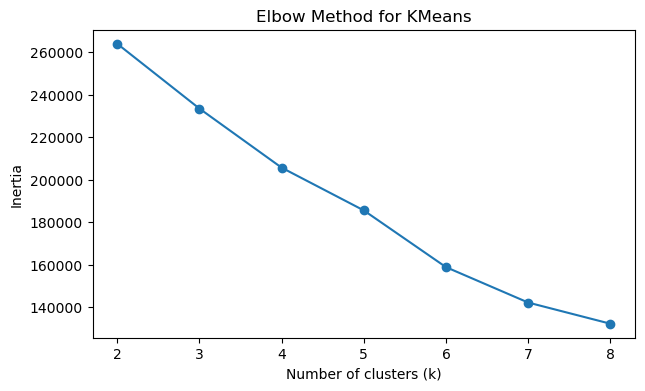

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(k_values, inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for KMeans")
plt.show()

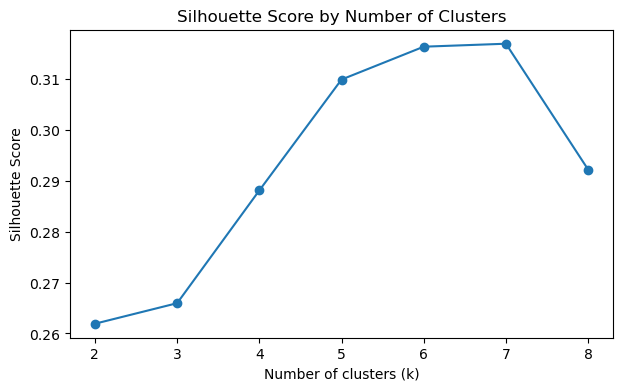

In [24]:
plt.figure(figsize=(7, 4))
plt.plot(k_values, sil_scores, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Number of Clusters")
plt.show()

We pick k = 6 where the inertia starts to flatten and the silhouette score is near the maximum.

In [53]:
k_final = 6

kmeans = KMeans(
    n_clusters=k_final,
    random_state=43210,
    n_init=20
)

clusters = kmeans.fit_predict(X_pca)

seg_data["cluster"] = clusters

In [54]:
# cluster sizes by datapoints
seg_data["cluster"].value_counts().sort_index()

cluster
0    39916
1      315
2    93358
3    61780
4     3779
5      375
Name: count, dtype: int64

In [55]:
# cluster sizes by population (with weights)

seg_data["weight"] = weights

cluster_population = seg_data.groupby("cluster")["weight"].sum()
cluster_population


cluster
0    6.844760e+07
1    5.480008e+05
2    1.655321e+08
3    1.052186e+08
4    6.831180e+06
5    6.684239e+05
Name: weight, dtype: float64

In [58]:
# population proportion

cluster_population / cluster_population.sum()

cluster
0    0.197116
1    0.001578
2    0.476700
3    0.303009
4    0.019672
5    0.001925
Name: weight, dtype: float64

Interpret the clusters

In [59]:
# helper functions

def weighted_mean(x, w):
    return np.sum(x * w) / np.sum(w)

def weighted_distribution(df, column):
    return (
        df.groupby(["cluster", column])["weight"]
        .sum()
        .groupby(level=0)
        .apply(lambda x: x / x.sum())
    )

def weighted_mode(series, weights):
    df = pd.DataFrame({"val": series, "w": weights})
    return df.groupby("val")["w"].sum().idxmax()

In [60]:
weighted_numeric_summary = seg_data.groupby("cluster").apply(
    lambda g: pd.Series({
        col: weighted_mean(g[col].fillna(g[col].median()), g["weight"])
        for col in numeric_cols
    })
)

print(weighted_numeric_summary)

               age  wage per hour  capital gains  capital losses  \
cluster                                                            
0        61.324933       0.211723     157.527498        0.508848   
1        58.726214      42.494204    7655.964495      152.402897   
2        38.300179     115.946713     429.047314        0.358009   
3        10.196236       1.177965       4.633511        0.000000   
4        43.545582      80.071674       0.000000     1934.302141   
5        46.239650      27.669028   99999.000000        0.000000   

         dividends from stocks  weeks worked in year  
cluster                                               
0                   311.352098              2.015420  
1                 37327.852637             24.840520  
2                   134.388653             46.161696  
3                     3.454177              0.747293  
4                   441.756695             41.790973  
5                  1786.181028             47.874094  


C:\Users\Zihao\AppData\Local\Temp\ipykernel_9168\3228495726.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weighted_numeric_summary = seg_data.groupby("cluster").apply(


In [61]:
weighted_distribution(seg_data, "education")

cluster  cluster  education                             
0        0        10th grade                                0.058119
                  11th grade                                0.041983
                  12th grade no diploma                     0.014032
                  1st 2nd 3rd or 4th grade                  0.025575
                  5th or 6th grade                          0.041148
                                                              ...   
5        5        Doctorate degree(PhD EdD)                 0.073795
                  High school graduate                      0.101389
                  Masters degree(MA MS MEng MEd MSW MBA)    0.143770
                  Prof school degree (MD DDS DVM LLB JD)    0.250018
                  Some college but no degree                0.088001
Name: weight, Length: 88, dtype: float64

In [62]:
for c in sorted(seg_data["cluster"].unique()):
    print(f"\nCluster {c} - education")

    dist = (
        seg_data[seg_data["cluster"] == c]
        .groupby("education")["weight"]
        .sum()
        .sort_values(ascending=False)
    )

    print((dist / dist.sum()).head(5))


Cluster 0 - education
education
High school graduate          0.361860
Some college but no degree    0.138154
7th and 8th grade             0.102241
Bachelors degree(BA AB BS)    0.083032
10th grade                    0.058119
Name: weight, dtype: float64

Cluster 1 - education
education
Bachelors degree(BA AB BS)                0.371299
Some college but no degree                0.166898
Masters degree(MA MS MEng MEd MSW MBA)    0.159271
High school graduate                      0.138481
Prof school degree (MD DDS DVM LLB JD)    0.054174
Name: weight, dtype: float64

Cluster 2 - education
education
High school graduate                      0.334221
Some college but no degree                0.212458
Bachelors degree(BA AB BS)                0.165655
Masters degree(MA MS MEng MEd MSW MBA)    0.052885
Associates degree-occup /vocational       0.042910
Name: weight, dtype: float64

Cluster 3 - education
education
Children                      0.751807
9th grade                     0.04308

In [63]:
numeric_summary_cols = [
    "age",
    "wage per hour",
    "weeks worked in year",
    "capital gains"
]

categorical_summary_cols = [
    "education",
    "marital stat",
    "major occupation code",
    "class of worker",
    "citizenship",
    "race",
    "sex"
]

In [64]:
rows = []

for c, g in seg_data.groupby("cluster"):
    
    row = {"cluster": c}
    
    # population share
    row["pop_%"] = g["weight"].sum() / seg_data["weight"].sum()
    
    # numeric summaries
    for col in numeric_summary_cols:
        row[col] = weighted_mean(g[col].fillna(g[col].median()), g["weight"])
    
    # categorical summaries
    for col in categorical_summary_cols:
        row[col] = weighted_mode(g[col], g["weight"])
    
    rows.append(row)

cluster_profile = pd.DataFrame(rows).sort_values("cluster")

cluster_profile

,cluster,pop_%,age,wage per hour,weeks worked in year,capital gains,education,marital stat,major occupation code,class of worker,citizenship,race,sex
0,0,0.197116,61.324933,0.211723,2.015420,157.527498,High school graduate,Married-civilian spouse present,Not in universe,Not in universe,Native- Born in the United States,White,Female
1,1,0.001578,58.726214,42.494204,24.840520,7655.964495,Bachelors degree(BA AB BS),Married-civilian spouse present,Not in universe,Not in universe,Native- Born in the United States,White,Male
2,2,0.476700,38.300179,115.946713,46.161696,429.047314,High school graduate,Married-civilian spouse present,Adm support including clerical,Private,Native- Born in the United States,White,Male
3,3,0.303009,10.196236,1.177965,0.747293,4.633511,Children,Never married,Not in universe,Not in universe,Native- Born in the United States,White,Male
4,4,0.019672,43.545582,80.071674,41.790973,0.000000,High school graduate,Married-civilian spouse present,Professional specialty,Private,Native- Born in the United States,White,Male
5,5,0.001925,46.239650,27.669028,47.874094,99999.000000,Bachelors degree(BA AB BS),Married-civilian spouse present,Professional specialty,Private,Native- Born in the United States,White,Male


In [65]:
cluster_profile["pop_%"] = (cluster_profile["pop_%"] * 100).round(1)

cluster_profile

,cluster,pop_%,age,wage per hour,weeks worked in year,capital gains,education,marital stat,major occupation code,class of worker,citizenship,race,sex
0,0,19.7,61.324933,0.211723,2.015420,157.527498,High school graduate,Married-civilian spouse present,Not in universe,Not in universe,Native- Born in the United States,White,Female
1,1,0.2,58.726214,42.494204,24.840520,7655.964495,Bachelors degree(BA AB BS),Married-civilian spouse present,Not in universe,Not in universe,Native- Born in the United States,White,Male
2,2,47.7,38.300179,115.946713,46.161696,429.047314,High school graduate,Married-civilian spouse present,Adm support including clerical,Private,Native- Born in the United States,White,Male
3,3,30.3,10.196236,1.177965,0.747293,4.633511,Children,Never married,Not in universe,Not in universe,Native- Born in the United States,White,Male
4,4,2.0,43.545582,80.071674,41.790973,0.000000,High school graduate,Married-civilian spouse present,Professional specialty,Private,Native- Born in the United States,White,Male
5,5,0.2,46.239650,27.669028,47.874094,99999.000000,Bachelors degree(BA AB BS),Married-civilian spouse present,Professional specialty,Private,Native- Born in the United States,White,Male
